# Assignment 1.2: Affine Transformation

### 1. Import Libraries

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2. Load Image

In [3]:
# Path to input image
image_path = "../assets/input/sample.jpg"

# Read image using OpenCV
image = cv2.imread(image_path)

if image is None:
    raise FileNotFoundError(f"Could not load image: {image_path}")

# Convert BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image shape:", image_rgb.shape)

Image shape: (480, 640, 3)


### 3. Display Original Image

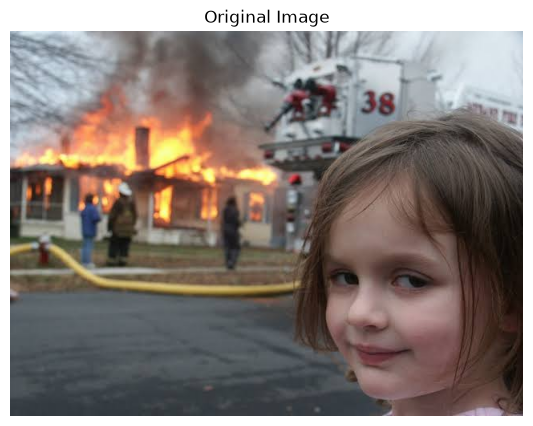

In [4]:
plt.figure(figsize=(7, 5))

plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.show()

### 4. Translation

In [5]:
height, width = image.shape[:2]

# Translation values
tx = 100   # horizontal translation
ty = 50    # vertical translation

# Translation matrix
translation_matrix = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

# Apply affine transformation
translated_image = cv2.warpAffine(
    image,
    translation_matrix,
    (width, height)
)

# Convert BGR to RGB
translated_rgb = cv2.cvtColor(
    translated_image,
    cv2.COLOR_BGR2RGB
)

### 5. Display Translation Result

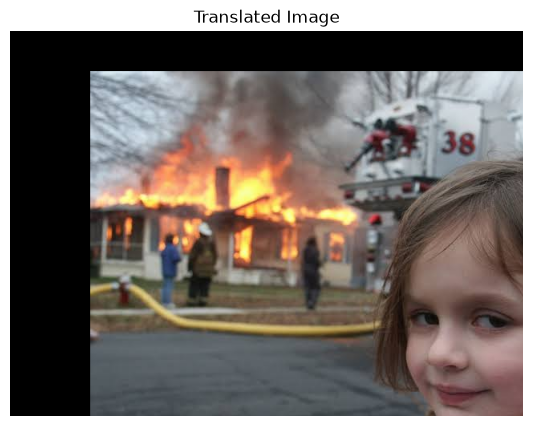

In [6]:
plt.figure(figsize=(7, 5))

plt.imshow(translated_rgb)
plt.title("Translated Image")
plt.axis("off")

plt.show()

### 6. Rotation

In [7]:
height, width = image.shape[:2]

# Rotation center
center = (width // 2, height // 2)

# Rotation angle
angle = 45

# Scale factor
scale = 1.0

# Rotation matrix
rotation_matrix = cv2.getRotationMatrix2D(
    center,
    angle,
    scale
)

# Apply rotation
rotated_image = cv2.warpAffine(
    image,
    rotation_matrix,
    (width, height)
)

# Convert BGR to RGB
rotated_rgb = cv2.cvtColor(
    rotated_image,
    cv2.COLOR_BGR2RGB
)

### 7. Display Rotation Result

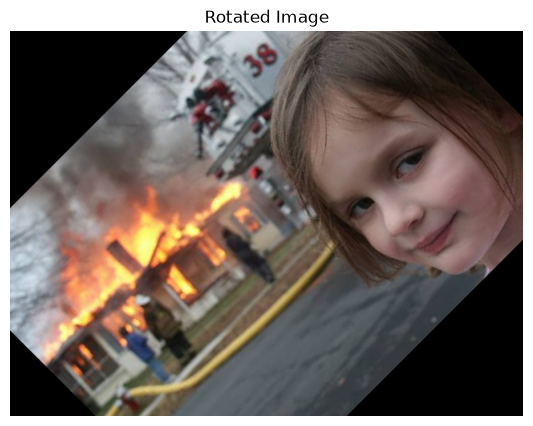

In [8]:
plt.figure(figsize=(7, 5))

plt.imshow(rotated_rgb)
plt.title("Rotated Image")
plt.axis("off")

plt.show()

### 8. Scaling

In [9]:
scale_x = 1.5
scale_y = 1.5

scaled_image = cv2.resize(
    image,
    None,
    fx=scale_x,
    fy=scale_y,
    interpolation=cv2.INTER_LINEAR
)

scaled_rgb = cv2.cvtColor(
    scaled_image,
    cv2.COLOR_BGR2RGB
)

print("Original size:", image.shape[1], "x", image.shape[0])
print("Scaled size:", scaled_image.shape[1], "x", scaled_image.shape[0])

Original size: 640 x 480
Scaled size: 960 x 720


### 9. Display Scaling Result

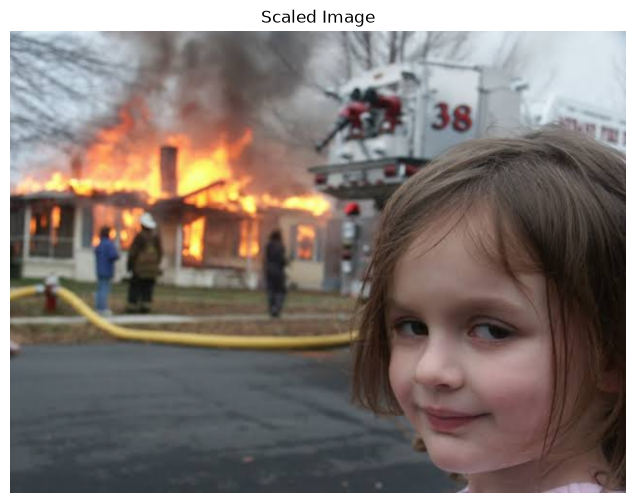

In [10]:
plt.figure(figsize=(8, 6))

plt.imshow(scaled_rgb)
plt.title("Scaled Image")
plt.axis("off")

plt.show()

### 10. Horizontal Shearing

In [11]:
height, width = image.shape[:2]

shear_x = 0.5

shear_matrix_x = np.float32([
    [1, shear_x, 0],
    [0, 1,       0]
])

sheared_x = cv2.warpAffine(
    image,
    shear_matrix_x,
    (width + int(height * shear_x), height)
)

sheared_x_rgb = cv2.cvtColor(
    sheared_x,
    cv2.COLOR_BGR2RGB
)

### 11. Display Horizontal Shearing

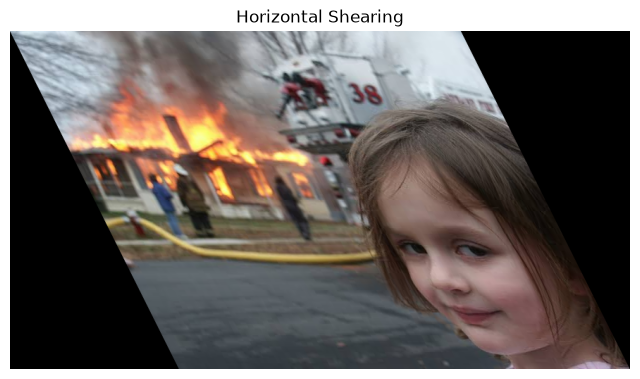

In [12]:
plt.figure(figsize=(8, 5))

plt.imshow(sheared_x_rgb)
plt.title("Horizontal Shearing")
plt.axis("off")

plt.show()

### 12. Vertical Shearing

In [13]:
shear_y = 0.5

shear_matrix_y = np.float32([
    [1, 0, 0],
    [shear_y, 1, 0]
])

sheared_y = cv2.warpAffine(
    image,
    shear_matrix_y,
    (width, height + int(width * shear_y))
)

sheared_y_rgb = cv2.cvtColor(
    sheared_y,
    cv2.COLOR_BGR2RGB
)

### 13. Display Vertical Shearing

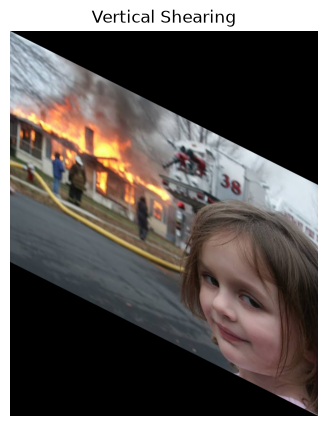

In [14]:
plt.figure(figsize=(8, 5))

plt.imshow(sheared_y_rgb)
plt.title("Vertical Shearing")
plt.axis("off")

plt.show()

### 14. General Affine Transformation

In [15]:
height, width = image.shape[:2]

# Three points from the original image
src_points = np.float32([
    [0, 0],
    [width - 1, 0],
    [0, height - 1]
])

# Corresponding destination points
dst_points = np.float32([
    [50, 50],
    [width - 100, 80],
    [80, height - 50]
])

# Calculate affine transformation matrix
affine_matrix = cv2.getAffineTransform(
    src_points,
    dst_points
)

print("Affine Transformation Matrix:")
print(affine_matrix)

# Apply affine transformation
affine_image = cv2.warpAffine(
    image,
    affine_matrix,
    (width, height)
)

# Convert BGR to RGB
affine_rgb = cv2.cvtColor(
    affine_image,
    cv2.COLOR_BGR2RGB
)

Affine Transformation Matrix:
[[7.66823161e-01 6.26304802e-02 5.00000000e+01]
 [4.69483568e-02 7.93319415e-01 5.00000000e+01]]


### 15. Display General Affine Transformation

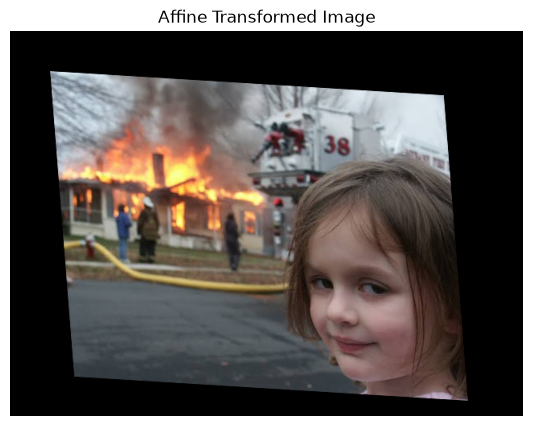

In [16]:
plt.figure(figsize=(7, 5))

plt.imshow(affine_rgb)
plt.title("Affine Transformed Image")
plt.axis("off")

plt.show()

### 16. Compare Transformations

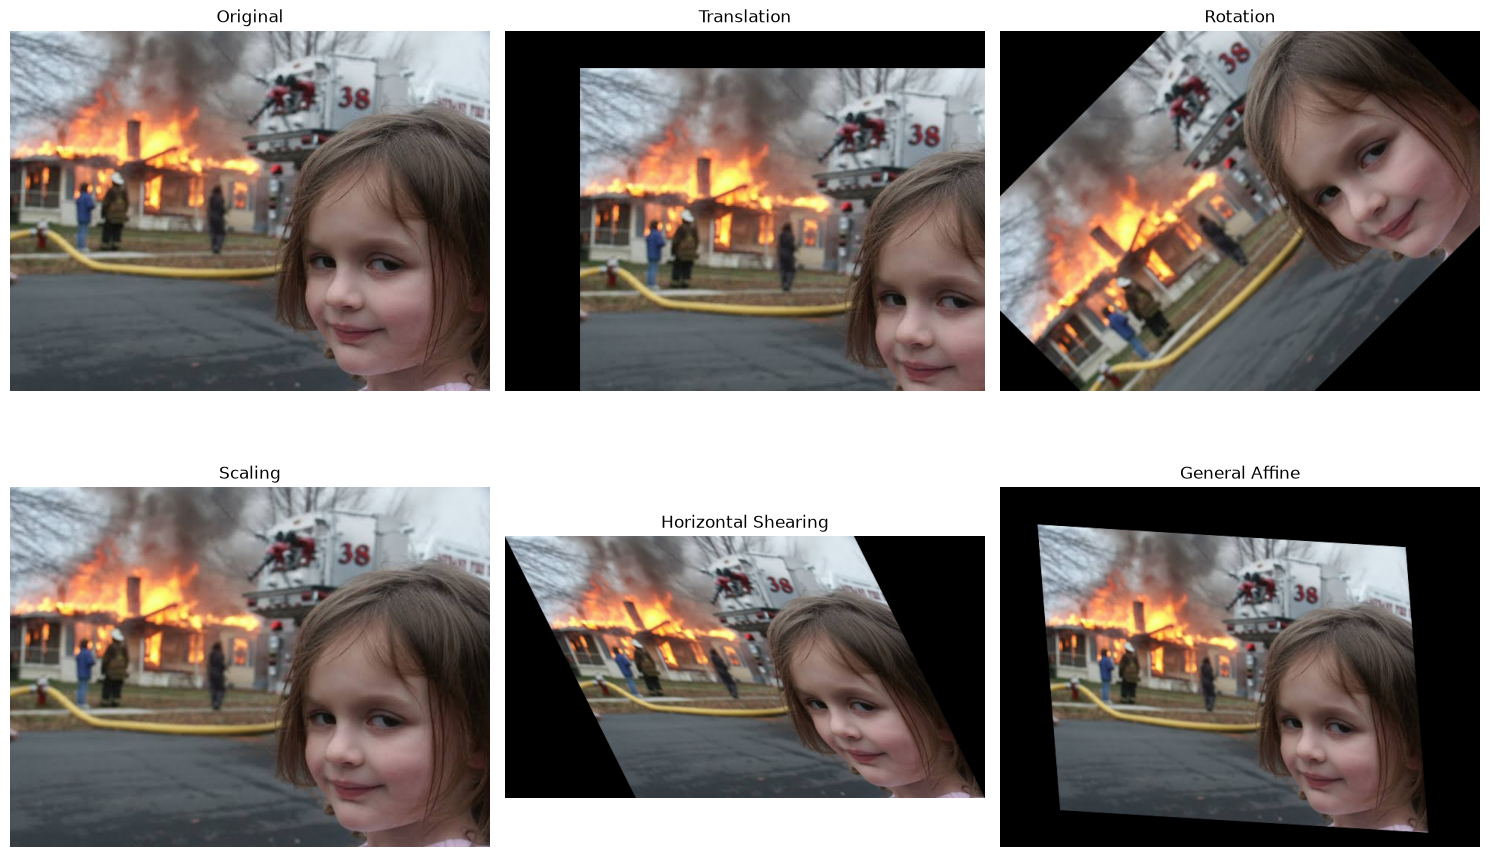

In [17]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 10)
)

# Original
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

# Translation
axes[0, 1].imshow(translated_rgb)
axes[0, 1].set_title("Translation")
axes[0, 1].axis("off")

# Rotation
axes[0, 2].imshow(rotated_rgb)
axes[0, 2].set_title("Rotation")
axes[0, 2].axis("off")

# Scaling
axes[1, 0].imshow(scaled_rgb)
axes[1, 0].set_title("Scaling")
axes[1, 0].axis("off")

# Horizontal shear
axes[1, 1].imshow(sheared_x_rgb)
axes[1, 1].set_title("Horizontal Shearing")
axes[1, 1].axis("off")

# General affine
axes[1, 2].imshow(affine_rgb)
axes[1, 2].set_title("General Affine")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()